In [1]:
from builtins import range
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from typing import List, Dict, Tuple

In [2]:
#: machine epsilon
EPS = np.finfo(float).eps
#: [1 W m-2 in umol m2 s-1], conversion from watts to micromol
PAR_TO_UMOL = 4.56
#: [1 ged in rad], conversion from deg to rad
DEG_TO_RAD = 3.14159 / 180.0

def kbeam(zen: float, x: float=1.0) -> float:
    """
    Attenuation coefficient for direc beam Kb [-] for given solar zenith angle zen [rad]
    and leaf angle distribution x [-]

    Reference: 
        Campbell & Norman. 1998., Introduction to environmental biophysics

    Args:
        zen (float|array): [rad], solar zenith angle
        x (float): [-], leaf-angle distr. parameter
                x = 1 : spherical leaf-angle distr. (default)
                x = 0 : vertical leaf-angle distr.
                x -> inf. : horizontal leaf-angle distr
    Returns:
        Kb (float|aray): [-], beam attenuation coefficient

    """

    zen = np.array(zen)
    x = np.array(x)

    XN1 = (np.sqrt(x*x + np.tan(zen)**2))
    XD1 = (x + 1.774*(x + 1.182)**(-0.733))
    Kb = XN1 / XD1  # direct beam

    Kb = np.minimum(15, Kb)

    return Kb

def kdiffuse(LAI: float, x: float=1.0) -> float:
    """
    Attenuation coefficient for isotropic diffuse ratioan Kd [-] obtained by integrating
    beam attenuation coefficient over hemisphere

    Reference:
        Campbell & Norman. 1998. Introduction to environmental biophysics, eq. 15.5
    Args:
        LAI (float): [m2 m-2], stand leaf (or plant) area index
        x (float): [-] leaf-angle distr. parameter
                x = 1 : spherical leaf-angle distr. (default)
                x = 0 : vertical leaf-angle distr.
                x = inf. : horizontal leaf-angle distr.
    Returns:
        (float):
        Kd (float): [-], diffuse attenuation coefficient

    """

    LAI = float(LAI)
    x = np.array(x)

    ang = np.linspace(0, np.pi / 2, 90)  # zenith angles at 1deg intervals
    dang = ang[1]-ang[0]

    # beam attenuation coefficient - call kbeam
    Kb = kbeam(ang, x)

    # integrate over hemisphere to get Kd, Campbell & Norman (1998, eq. 15.5)
    YY = np.exp(-Kb*LAI)*np.sin(ang)*np.cos(ang)

    Taud = 2.0*np.trapz(YY*dang)
    Kd = -np.log(Taud) / (LAI + EPS)  # extinction coefficient for diffuse radiation

    return Kd

In [3]:

def canopy_sw_ZhaoQualls(LAIz: np.ndarray, Clump: float, x: float, Zen: float, 
                         IbSky: float, IdSky:float, LeafAlbedo: float, SoilAlbedo: float
                         , PlotFigs: bool=False) -> Tuple:
    """
    Computes short-wave (SW) radiation transfer inside horizontally homogeneous multi-layer canopy. Includes
    multiple reflections between foliage layers and soil surface.

    Reference:
        Zhao W. & Qualls R.J. (2005). A multiple-layer canopy scattering model
        to simulate shortwave radiation distribution within a homogenous plant
        canopy. Water Resources Res. 41, W08409, 1-16.

    Note: 
        To get sunlit fraction below all vegetation: f_sl[0].

        At least for conifers NIR LeafAlbedo has to be decreased from leaf-scale  values to correctly 
        model canopy albedo of clumped canopies. Adjustment from ~0.7 to 0.55 seems to be sufficient.
        This corresponds roughlty to a=a_needle*[4*STAR / (1- a_needle*(1-4*STAR))], where a_needle is needle albedo
        and STAR silhouette to total area ratio of a conifer shoot. STAR ~0.09-0.21 (mean 0.14)
        for Scots pine (Smolander, Stenberg et al. -papers)

    Args:
        LAIz (array): [m2 m-2 (ground)], layewise one-sided leaf-area index
        Clump (float): [-], element clumping index
        x (float): [-], param. of leaf angle distribution (1=spherical, 0=vertical, ->inf.=horizontal)
        Zen (float): [rad], solar zenith angle
        IbSky (float): [W m-2], incident direct (beam) radiation above canopy
        IdSky (float): [W m-2], downwelling diffuse radiation above canopy
        LeafAlbedo (float): [-], leaf albedo of desired waveband
        SoilAlbedo (float): [-], soil albedo of desired waveband
        PlotFigs (bool): plot figures

    Returns:
        (tuple):
            SWbo (array): [W m-2 (ground)], direct radiation; 
            SWdo (array): [W m-2 (ground)], downwelling diffuse radiation; 
            SWuo (array): [W m-2 (ground)], upwelling diffuse; 
            Q_sl (array): [W m-2 (eff. leaf)] incident SW per unit sunlit effective (clumped) leaf area; 
            Q_sh: (array): [W m-2 (eff. leaf)] incident SW per unit shaded effective (clumped) leaf area; 
            q_sl: (array): [W m-2 (eff. leaf)], absorbed SW per unit sunlit effective (clumped) leaf area; 
            q_sh: (array): [W m-2 (eff. leaf)], absorbed SW per unit shaded effective (clumped) leaf area; 
            q_soil (float): [W m-2 (ground)], absorbed SW by ground; 
            f_sl: (array): [-] sunlit fraction of physical leaf area (= exp(-Kb*Lcumo));
                           multiply by Lo=Clump*LAIz for sunlit eff. leaf area, (1-f_sl)*Lo for shaded eff. leaf area;
            alb (array): [-] ecosystem SW albedo; 
    
    """
    # --- check inputs and create local variables
    IbSky = max(IbSky, 0.0001)
    IdSky = max(IdSky, 0.0001)

    # original and computational grid
    LAI = Clump*sum(LAIz)  # effective LAI, corrected for clumping (m2 m-2)

    Lo = Clump*LAIz  # effective layerwise LAI (or PAI) in original grid

    Lcumo = np.cumsum(np.flipud(Lo), 0)  # cumulative plant area index from canopy top
    Lcumo = np.flipud(Lcumo)  # node 0 is canopy bottom, N is top

    # --- create computation grid
    N = np.size(Lo)  # nr of original layers
    M = np.minimum(100, N)  # nr of comp. layers
    L = np.ones([M+2])*LAI / M  # effective leaf-area density (m2m-3)
    L[0] = 0.
    L[M + 1] = 0.
    Lcum = np.cumsum(np.flipud(L), 0)  # cumulative plant area from top

    # ---- optical parameters
    aL = np.ones([M+2])*(1 - LeafAlbedo)  # leaf absorptivity
    tL = np.ones([M+2])*0.4  # transmission as fraction of scattered radiation
    rL = np.ones([M+2])*0.6  # reflection as fraction of scattered radiation

    # soil surface, no transmission
    aL[0] = 1. - SoilAlbedo
    tL[0] = 0.
    rL[0] = 1.

    # upper boundary = atm. is transparent for SW
    aL[M+1] = 0.
    tL[M+1] = 1.
    rL[M+1] = 0.

    # black leaf extinction coefficients for direct beam and diffuse radiation
    Kb = kbeam(Zen, x)
    Kd = kdiffuse(LAI, x)

    # fraction of sunlit & shad ground area in a layer (-)
    f_sl = np.flipud(np.exp(-Kb*(Lcum)))

    # beam radiation at each layer
    Ib = f_sl*IbSky

    # propability for beam and diffuse penetration through layer without interception
    taub = np.zeros([M+2])
    taud = np.zeros([M+2])
    taub[0:M+2] = np.exp(-Kb*L)
    taud[0:M+2] = np.exp(-Kd*L)

    # soil surface is non-transparent
    taub[0] = 0.
    taud[0] = 0.

    # backward-scattering functions (eq. 22-23) for beam rb and diffuse rd
    rb = np.zeros([M+2])
    rd = np.zeros([M+2])
    rb = 0.5 + 0.3334*(rL - tL) / (rL + tL)*np.cos(Zen)
    rd = 2.0 / 3.0*rL/(rL + tL) + 1.0 / 3.0*tL / (rL + tL)

    rb[0] = 1.
    rd[0] = 1.
    rb[M+1] = 0.
    rd[M+1] = 0.

    # --- set up tridiagonal matrix A and solve SW without multiple scattering
    # from A*SW = C (Zhao & Qualls, 2006. eq. 39 & 42)
    A = np.zeros([2*M+2, 2*M+2])

    # lowermost rows: 0 = soil surface, M+2 is upper boundary
    A[0, 0] = 1.

    A[1, 0] = - (taud[1] + (1 - taud[1])*(1 - aL[1])*(1 - rd[1]))
    A[1, 1] = - 1*(taud[1] + (1 - taud[1])*(1 - aL[1])*(1 - rd[1]))*(1 - aL[0])
    A[1, 2] = (1 - 1*rd[1]*(1 - aL[0])*1*(1 - aL[1])*(1 - taud[1]))

    # middle rows
    for k in range(1, M + 1):
        A[2*k-1, 2*k-2] = - (taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))
        A[2*k-1, 2*k-1] = - rd[k - 1]*(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))*(1 - aL[k-1])*(1 - taud[k-1])
        A[2*k-1, 2*k] = (1 - rd[k-1]*rd[k]*(1 - aL[k-1])*(1 - taud[k-1])*(1 - aL[k])*(1 - taud[k]))

        A[2*k, 2*k-1] = (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        A[2*k, 2*k] = - rd[k+1]*(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))*(1 - aL[k+1])*(1 - taud[k+1])
        A[2*k, 2*k+1] = -(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))

    # uppermost node2*M+2
    A[2*M+1, 2*M+1] = 1.
    del k

    # --- RHS vector C
    C = np.zeros([2*M+2, 1])

    # lowermost row
    C[0] = SoilAlbedo*Ib[0]
    n = 1  # dummy
    for k in range(1, M+1):  # k=2:M-1,
        C[n] = (1 - rd[k-1]*rd[k]*(1 - aL[k-1])*(1 - taud[k-1])*(1 - aL[k])*(1 - taud[k]) )*rb[k]*(1 - taub[k])*(1 - aL[k])*Ib[k]
        C[n+1] = (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))*(1 - taub[k])*(1 - aL[k])*(1 - rb[k])*Ib[k]
        # Ib(k+1) instead of Ib(k):n as we need radiation incoming to the layer k.
        n = n + 2

    # uppermost row
    C[2*M+1] = IdSky

    # ---- solve A*SW = C
    SW = np.linalg.solve(A, C)

    # upward and downward hemispherical radiation (Wm-2 ground)
    SWu0 = SW[0:2*M+2:2]
    SWd0 = SW[1:2*M+2:2]
    del A, C, SW, k

    # ---- Compute multiple scattering, Zhao & Qualls, 2005. eq. 24 & 25.
    # downwelling diffuse after multiple scattering, eq. 24
    SWd = np.zeros([M+1])
    for k in range(M-1, -1, -1):  # downwards from layer k+1 to layer k
        X = SWd0[k+1] / (1 - rd[k]*rd[k+1]*(1-aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        Y = SWu0[k]*rd[k+1]*(1 - aL[k+1])*(1 - taud[k+1]) / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        SWd[k+1] = X + Y
    SWd[0] = SWd[1]

    # upwelling diffuse after multiple scattering, eq. 25
    SWu = np.zeros([M+1])
    for k in range(0, M, 1):  # upwards from layer k to layer k+1
        X = SWu0[k] / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        Y = SWd0[k+1]*rd[k]*(1 - aL[k])*(1 - taud[k]) / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        SWu[k] = X + Y
    SWu[M] = SWu[M-1]

    # match dimensions of all vectors
    Ib = Ib[1:M+2]
    f_sl = f_sl[1:M+2]
    Lcum = np.flipud(Lcum[0:M+1])
    aL = aL[0:M+1]

    # --- NOW return values back to the original grid
    f_slo = np.exp(-Kb*(Lcumo))       # sunlit fraction of physical leaf area (= exp(-Kb * Clump * cumsum(LAIz)))
    SWbo = f_slo*IbSky                # Beam radiation

    # interpolate diffuse fluxes
    X = np.flipud(Lcumo)
    xi = np.flipud(Lcum)
    SWdo = np.flipud(np.interp(X, xi, np.flipud(SWd)))
    SWuo = np.flipud(np.interp(X, xi, np.flipud(SWu)))
    del X, xi

    # stand albedo
    alb = SWuo[-1] / (IbSky + IdSky + EPS)
    # soil absorption (Wm-2 (ground))
    q_soil = (1 - SoilAlbedo)*(SWdo[0] + SWbo[0])

    #--- absorbed components per layer (per unit effective leaf area) ---
    # Exact flux-divergence formulation.
    # Arrays SWbo/SWdo/SWuo[k] are at the BOTTOM of layer k (index 0 = canopy bottom).
    # Top-of-layer k = bottom-of-layer k+1, except for the topmost layer where
    # canopy-top upwelling is approximated as SWuo[-1] (exact for all other layers).
    aLo = np.ones(len(Lo))*(1 - LeafAlbedo)

    SWdo_top = np.append(SWdo[1:], IdSky)
    SWuo_top = np.append(SWuo[1:], SWuo[-1])  # approx for top layer only
    SWbo_top = np.append(SWbo[1:], IbSky)

    # Total absorbed per layer [W m-2 ground] = divergence of net downward flux
    total_abs = (SWbo_top + SWdo_top - SWuo_top) - (SWbo + SWdo - SWuo)

    # Beam absorbed per layer [W m-2 ground]
    abs_beam = aLo * (SWbo_top - SWbo)

    # absorbed per unit effective (clumped) LAI [W m-2 eff. leaf]
    aDiffo = (total_abs - abs_beam) / np.maximum(Lo, EPS)   # diffuse; per unit Lo
    aDiro  = abs_beam / np.maximum(f_slo * Lo, EPS)         # beam; per unit sunlit Lo

    # --- Sunlit / shaded split, energy-conserving ---
    # Beam is absorbed only by sunlit leaves; diffuse is uniform per effective leaf area.
    # All quantities remain per unit effective (clumped) LAI.
    #
    # Conservation check:
    #   q_sl*f_slo*Lo + q_sh*(1-f_slo)*Lo
    #   = (aDiffo+aDiro)*f_slo*Lo + aDiffo*(1-f_slo)*Lo
    #   = Lo*(aDiffo + aDiro*f_slo) = total_abs  [exact]
    q_sh = aDiffo                    # [W m-2 eff. leaf], shaded
    q_sl = aDiffo + aDiro            # [W m-2 eff. leaf], sunlit

    # Incident per unit effective leaf area: Q = q / (1 - LeafAlbedo)
    Q_sl = q_sl / aLo
    Q_sh = q_sh / aLo

    if PlotFigs:
        fig, ax = plt.subplots(2,2, figsize=(8,10))

        # add input parameter values to fig
        ax[0,0].text(0.05, 0.65, r'$LAI$ = %1.1f m2 m-2' % (LAI))
        ax[0,0].text(0.50, 0.65, r'$ZEN$ = %1.1f ' % (Zen / DEG_TO_RAD))
        ax[0,0].text(0.75, 0.65, r'$\alpha_l$ = %0.2f' % (LeafAlbedo))
        ax[0,0].text(1.0, 0.65, r'$\alpha_s$ = %0.2f' % (SoilAlbedo))

        ax[0,0].set_title("Source: radiation.canopy_sw_ZhaoQualls")

        ax[0,0].plot(f_slo, -Lcumo/Clump, 'r-', (1 - f_slo), -Lcumo/Clump, 'b-')
        ax[0,0].set_ylabel("-Lcum / Clump")
        ax[0,0].set_xlabel("sunlit & shaded fractions (-)")
        ax[0,0].legend(('f$_{sl}$, LAI$_{sl}$ = %.2f' % np.sum(f_slo*Lo), 'f$_{sh}$, LAI$_{sh}$ = %.2f' % np.sum((1 - f_slo)*Lo)), loc='best')

        ax[0,1].plot(Q_sl, -Lcumo/Clump, 'ro-', Q_sh, -Lcumo/Clump, 'bo-')
        ax[0,1].set_ylabel("-Lcum / Clump")
        ax[0,1].set_xlabel("Incident radiation (Wm-2 (eff. leaf))")
        ax[0,1].legend(('Q$_{sl}$ sunlit', 'Q$_{sh}$ shaded'), loc='best')

        ax[1,0].plot(SWd, -Lcum/Clump, 'bo', SWdo, -Lcumo/Clump, 'b-', Ib, -Lcum/Clump, 'ro',
                 SWbo, -Lcumo/Clump, 'r-', SWu, -Lcum/Clump, 'go', SWuo, -Lcumo/Clump, 'g-')
        ax[1,0].legend(('SWd', 'Swdo', 'SWb', 'SWbo', 'SWu', 'SWuo'), loc='best')
        ax[1,0].set_ylabel("-Lcum / Clump")
        ax[1,0].set_xlabel("Incident SW (Wm-2 )")

        ax[1,1].plot(q_sl, -Lcumo/Clump, 'ro-', q_sh, -Lcumo/Clump, 'bo-')
        ax[1,1].set_ylabel("-Lcum / Clump")
        ax[1,1].set_xlabel("Absorbed radiation (Wm-2 (eff. leaf))")
        ax[1,1].legend(('q$_{sl}$ sunlit', 'q$_{sh}$ shaded'), loc='best')

    return SWbo, SWdo, SWuo, Q_sl, Q_sh, q_sl, q_sh, q_soil, f_slo, alb


In [ ]:

def canopy_sw_ZhaoQualls_unclumped(LAIz: np.ndarray, Clump: float, x: float, Zen: float, 
                         IbSky: float, IdSky:float, LeafAlbedo: float, SoilAlbedo: float
                         , PlotFigs: bool=False) -> Tuple:
    """
    Computes short-wave (SW) radiation transfer inside horizontally homogeneous multi-layer canopy using two-stream approach.
    Includes multiple reflections between foliage layers and soil surface.

    Reference:
        Zhao W. & Qualls R.J. (2005). A multiple-layer canopy scattering model
        to simulate shortwave radiation distribution within a homogenous plant
        canopy. Water Resources Res. 41, W08409, 1-16.

    Note: 
        To get sunlit fraction below all vegetation: f_sl[0] / Clump.

        Within-clump shading is accounted for by conceptualizing three leaf pools:
          1. Truly sunlit (outer clump surface): fraction f_sl = Clump * exp(-Kb * Clump * LAI_cum) of physical LAI.
             These leaves receive full direct beam + diffuse.
          2. Within-clump self-shaded: fraction (1-Clump) * exp(-Kb * Clump * LAI_cum) of physical LAI.
             These leaves are in a sunlit clump but shielded inside it; receive diffuse only.
          3. Canopy-shaded: fraction 1 - exp(-Kb * Clump * LAI_cum) of physical LAI.
             Receive diffuse only.
        Pools 2 and 3 are merged into a single shaded pool with f_sh = 1 - Clump * exp(-Kb * Clump * LAI_cum).

    Args:
        LAIz (array): [m2 m-2 (ground)], layewise one-sided leaf-area index
        Clump (float): [-], element clumping index
        x (float): [-], param. of leaf angle distribution (1=spherical, 0=vertical, ->inf.=horizontal)
        Zen (float): [rad], solar zenith angle
        IbSky (float): [W m-2], incident direct (beam) radiation above canopy
        IdSky (float): [W m-2], downwelling diffuse radiation above canopy
        LeafAlbedo (float): [-], leaf albedo of desired waveband
        SoilAlbedo (float): [-], soil albedo of desired waveband
        PlotFigs (bool): plot figures

    Returns:
        (tuple):
            SWbo (array): [W m-2 (ground)], direct radiation; 
            SWdo (array): [W m-2 (ground)], downwelling diffuse radiation; 
            SWuo (array): [W m-2 (ground)], upwelling diffuse; 
            Q_sl (array): [W m-2 (leaf)] incident SW per unit truly sunlit un-clumped (physical) leaf area; 
            Q_sh: (array): [W m-2 (leaf)] incident SW per unit shaded un-clumped (physical) leaf area; 
            q_sl: (array): [W m-2 (leaf)], absorbed SW per unit truly sunlit un-clumped (physical) leaf area; 
            q_sh: (array): [W m-2 (leaf)], absorbed SW per unit shaded un-clumped (physical) leaf area; 
            q_soil (float): [W m-2 (ground)], absorbed SW by ground; 
            f_sl: (array): [-] truly sunlit fraction of physical leaf area = Clump * exp(-Kb*Clump*LAI_cum);
                           = outer clump surface fraction; within-clump self-shaded leaves are in shaded pool;
                           multiply by LAIz for truly sunlit physical leaf area per layer;
            alb (array): [-] ecosystem SW albedo; 
    
    """
    # --- check inputs and create local variables
    IbSky = max(IbSky, 0.0001)
    IdSky = max(IdSky, 0.0001)

    # original and computational grid
    LAI = Clump*sum(LAIz)  # effective LAI, corrected for clumping (m2 m-2)

    Lo = Clump*LAIz  # effective layerwise LAI (or PAI) in original grid

    Lcumo = np.cumsum(np.flipud(Lo), 0)  # cumulative plant area index from canopy top
    Lcumo = np.flipud(Lcumo)  # node 0 is canopy bottom, N is top

    # --- create computation grid
    N = np.size(Lo)  # nr of original layers
    M = np.minimum(100, N)  # nr of comp. layers
    L = np.ones([M+2])*LAI / M  # effective leaf-area density (m2m-3)
    L[0] = 0.
    L[M + 1] = 0.
    Lcum = np.cumsum(np.flipud(L), 0)  # cumulative plant area from top

    # ---- optical parameters
    aL = np.ones([M+2])*(1 - LeafAlbedo)  # leaf absorptivity
    tL = np.ones([M+2])*0.4  # transmission as fraction of scattered radiation
    rL = np.ones([M+2])*0.6  # reflection as fraction of scattered radiation

    # soil surface, no transmission
    aL[0] = 1. - SoilAlbedo
    tL[0] = 0.
    rL[0] = 1.

    # upper boundary = atm. is transparent for SW
    aL[M+1] = 0.
    tL[M+1] = 1.
    rL[M+1] = 0.

    # black leaf extinction coefficients for direct beam and diffuse radiation
    Kb = kbeam(Zen, x)
    Kd = kdiffuse(LAI, x)

    # fraction of sunlit & shad ground area in a layer (-)
    f_sl = np.flipud(np.exp(-Kb*(Lcum)))

    # beam radiation at each layer
    Ib = f_sl*IbSky

    # propability for beam and diffuse penetration through layer without interception
    taub = np.zeros([M+2])
    taud = np.zeros([M+2])
    taub[0:M+2] = np.exp(-Kb*L)
    taud[0:M+2] = np.exp(-Kd*L)

    # soil surface is non-transparent
    taub[0] = 0.
    taud[0] = 0.

    # backward-scattering functions (eq. 22-23) for beam rb and diffuse rd
    rb = np.zeros([M+2])
    rd = np.zeros([M+2])
    rb = 0.5 + 0.3334*(rL - tL) / (rL + tL)*np.cos(Zen)
    rd = 2.0 / 3.0*rL/(rL + tL) + 1.0 / 3.0*tL / (rL + tL)

    rb[0] = 1.
    rd[0] = 1.
    rb[M+1] = 0.
    rd[M+1] = 0.

    # --- set up tridiagonal matrix A and solve SW without multiple scattering
    # from A*SW = C (Zhao & Qualls, 2006. eq. 39 & 42)
    A = np.zeros([2*M+2, 2*M+2])

    # lowermost rows: 0 = soil surface, M+2 is upper boundary
    A[0, 0] = 1.

    A[1, 0] = - (taud[1] + (1 - taud[1])*(1 - aL[1])*(1 - rd[1]))
    A[1, 1] = - 1*(taud[1] + (1 - taud[1])*(1 - aL[1])*(1 - rd[1]))*(1 - aL[0])
    A[1, 2] = (1 - 1*rd[1]*(1 - aL[0])*1*(1 - aL[1])*(1 - taud[1]))

    # middle rows
    for k in range(1, M + 1):
        A[2*k-1, 2*k-2] = - (taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))
        A[2*k-1, 2*k-1] = - rd[k - 1]*(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))*(1 - aL[k-1])*(1 - taud[k-1])
        A[2*k-1, 2*k] = (1 - rd[k-1]*rd[k]*(1 - aL[k-1])*(1 - taud[k-1])*(1 - aL[k])*(1 - taud[k]))

        A[2*k, 2*k-1] = (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        A[2*k, 2*k] = - rd[k+1]*(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))*(1 - aL[k+1])*(1 - taud[k+1])
        A[2*k, 2*k+1] = -(taud[k] + (1 - taud[k])*(1 - aL[k])*(1 - rd[k]))

    # uppermost node2*M+2
    A[2*M+1, 2*M+1] = 1.
    del k

    # --- RHS vector C
    C = np.zeros([2*M+2, 1])

    # lowermost row
    C[0] = SoilAlbedo*Ib[0]
    n = 1  # dummy
    for k in range(1, M+1):  # k=2:M-1,
        C[n] = (1 - rd[k-1]*rd[k]*(1 - aL[k-1])*(1 - taud[k-1])*(1 - aL[k])*(1 - taud[k]) )*rb[k]*(1 - taub[k])*(1 - aL[k])*Ib[k]
        C[n+1] = (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))*(1 - taub[k])*(1 - aL[k])*(1 - rb[k])*Ib[k]
        # Ib(k+1) instead of Ib(k):n as we need radiation incoming to the layer k.
        n = n + 2

    # uppermost row
    C[2*M+1] = IdSky

    # ---- solve A*SW = C
    SW = np.linalg.solve(A, C)

    # upward and downward hemispherical radiation (Wm-2 ground)
    SWu0 = SW[0:2*M+2:2]
    SWd0 = SW[1:2*M+2:2]
    del A, C, SW, k

    # ---- Compute multiple scattering, Zhao & Qualls, 2005. eq. 24 & 25.
    # downwelling diffuse after multiple scattering, eq. 24
    SWd = np.zeros([M+1])
    for k in range(M-1, -1, -1):  # downwards from layer k+1 to layer k
        X = SWd0[k+1] / (1 - rd[k]*rd[k+1]*(1-aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        Y = SWu0[k]*rd[k+1]*(1 - aL[k+1])*(1 - taud[k+1]) / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        SWd[k+1] = X + Y
    SWd[0] = SWd[1]

    # upwelling diffuse after multiple scattering, eq. 25
    SWu = np.zeros([M+1])
    for k in range(0, M, 1):  # upwards from layer k to layer k+1
        X = SWu0[k] / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        Y = SWd0[k+1]*rd[k]*(1 - aL[k])*(1 - taud[k]) / (1 - rd[k]*rd[k+1]*(1 - aL[k])*(1 - taud[k])*(1 - aL[k+1])*(1 - taud[k+1]))
        SWu[k] = X + Y
    SWu[M] = SWu[M-1]

    # match dimensions of all vectors
    Ib = Ib[1:M+2]
    f_sl = f_sl[1:M+2]
    Lcum = np.flipud(Lcum[0:M+1])
    aL = aL[0:M+1]

    # --- NOW return values back to the original grid
    # Between-clump sunlit fraction of ground area (= exp(-Kb * Clump * cumsum(LAIz))).
    # Used only to derive SWbo; NOT returned as f_sl.
    f_slo = np.exp(-Kb*(Lcumo))
    SWbo = f_slo*IbSky                # Beam radiation at each level [W m-2 ground]

    # Truly sunlit fraction of physical leaf area = Clump * f_slo.
    # Physical interpretation: only the outer clump surface (fraction Clump of physical LAI)
    # is exposed to direct beam; the inner (1-Clump) fraction is always within-clump self-shaded.
    f_slo_true = Clump * f_slo

    # interpolate diffuse fluxes
    X = np.flipud(Lcumo)
    xi = np.flipud(Lcum)
    SWdo = np.flipud(np.interp(X, xi, np.flipud(SWd)))
    SWuo = np.flipud(np.interp(X, xi, np.flipud(SWu)))
    del X, xi

    # stand albedo
    alb = SWuo[-1] / (IbSky + IdSky + EPS)
    # soil absorption (Wm-2 (ground))
    q_soil = (1 - SoilAlbedo)*(SWdo[0] + SWbo[0])

    #--- absorbed components per layer (per unit un-clumped / physical leaf area) ---
    # Exact flux-divergence formulation.
    # Arrays SWbo/SWdo/SWuo[k] are at the BOTTOM of layer k (index 0 = canopy bottom).
    # Top-of-layer k = bottom-of-layer k+1, except for the topmost layer where
    # canopy-top upwelling is approximated as SWuo[-1] (exact for all other layers).
    aLo = np.ones(len(Lo))*(1 - LeafAlbedo)

    SWdo_top = np.append(SWdo[1:], IdSky)
    SWuo_top = np.append(SWuo[1:], SWuo[-1])  # approx for top layer only
    SWbo_top = np.append(SWbo[1:], IbSky)

    # Total absorbed per layer [W m-2 ground] = divergence of net downward flux
    total_abs = (SWbo_top + SWdo_top - SWuo_top) - (SWbo + SWdo - SWuo)

    # Beam absorbed per layer [W m-2 ground]
    abs_beam = aLo * (SWbo_top - SWbo)

    # Absorbed per unit physical leaf area [W m-2 physical leaf].
    # Dividing abs_beam by (f_slo_true * LAIz) = (Clump * f_slo * LAIz) gives the full
    # direct beam per truly sunlit leaf: aDiro ≈ aL * Kb * IbSky  (sun-angle-projected beam).
    # The (1-Clump)*f_slo within-clump self-shaded leaves and the (1-f_slo) canopy-shaded
    # leaves are all merged into the shaded pool and receive only diffuse (aDiffo).
    aDiffo = (total_abs - abs_beam) / np.maximum(LAIz, EPS)        # diffuse; per unit LAIz
    aDiro  = abs_beam / np.maximum(f_slo_true * LAIz, EPS)         # beam; per unit truly sunlit LAIz

    # --- Sunlit / shaded split, energy-conserving ---
    # f_slo_true = Clump * exp(-Kb * Clump * LAI_cum) is the truly sunlit fraction.
    # Shaded pool = within-clump self-shaded [(1-Clump)*f_slo] + canopy-shaded [1-f_slo].
    #
    # Conservation check:
    #   q_sl * f_slo_true * LAIz + q_sh * (1 - f_slo_true) * LAIz
    #   = (aDiffo + aDiro) * f_slo_true * LAIz + aDiffo * (1 - f_slo_true) * LAIz
    #   = aDiffo * LAIz + aDiro * f_slo_true * LAIz
    #   = (total_abs - abs_beam) + abs_beam = total_abs  [exact]
    q_sh = aDiffo                    # [W m-2 physical leaf], shaded (incl. within-clump self-shaded)
    q_sl = aDiffo + aDiro            # [W m-2 physical leaf], truly sunlit

    # Incident per unit physical leaf area: Q = q / (1 - LeafAlbedo)
    Q_sl = q_sl / aLo
    Q_sh = q_sh / aLo

    # --- for diagonstics ---
    if PlotFigs:
        depth = -Lcumo / Clump   # y-axis: 0 near top, -LAI/Clump at bottom

        # --- conservation quantities ---
        SWbo_int = np.append(SWbo, IbSky)
        SWdo_int = np.append(SWdo, IdSky)
        SWuo_int = np.append(SWuo, alb * (IbSky + IdSky))
        net_down  = SWbo_int + SWdo_int - SWuo_int
        abs_flux  = np.diff(net_down)
        abs_leaf  = q_sl * f_slo_true * LAIz + q_sh * (1 - f_slo_true) * LAIz

        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        fig.suptitle(
            f"canopy_sw_ZhaoQualls_unclumped  LAI={sum(LAIz):.1f} m2 m-2,  Zen={Zen/DEG_TO_RAD:.0f} deg,"
            f"  Clump={Clump},  aL={LeafAlbedo},  as={SoilAlbedo}",
            fontsize=11)

        # SW flux profiles
        ax = axes[0, 0]
        ax.plot(SWbo, depth, 'r-o', ms=4, label='Direct beam SWbo')
        ax.plot(SWdo, depth, 'b-o', ms=4, label='Diffuse down SWdo')
        ax.plot(SWuo, depth, 'g-o', ms=4, label='Diffuse up SWuo')
        ax.set_xlabel('Flux [W m-2 ground]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('SW flux profiles')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Three-pool fractions
        ax = axes[0, 1]
        ax.plot(f_slo_true, depth, 'r-o', ms=4,
                label=r'f$_{sl}$ truly sunlit = $\Omega \cdot e^{-K_b \Omega L}$')
        ax.plot((1 - Clump) * f_slo, depth, 'm--o', ms=4,
                label=r'within-clump self-shaded = $(1-\Omega) \cdot e^{-K_b \Omega L}$')
        ax.plot(1 - f_slo, depth, 'b-o', ms=4,
                label=r'canopy-shaded = $1 - e^{-K_b \Omega L}$')
        ax.plot(1 - f_slo_true, depth, 'k--o', ms=4,
                label=r'total shaded = $1 - \Omega \cdot e^{-K_b \Omega L}$')
        ax.set_xlabel('Fraction [-]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('Three-pool leaf fractions')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 1)

        # Incident per physical leaf area
        ax = axes[0, 2]
        ax.plot(Q_sl, depth, 'r-o', ms=4, label='Q_sl truly sunlit')
        ax.plot(Q_sh, depth, 'b-o', ms=4, label='Q_sh shaded')
        ax.set_xlabel('Incident [W m-2 physical leaf]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('Incident radiation per physical leaf area')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Absorbed per physical leaf area
        ax = axes[1, 0]
        ax.plot(q_sl, depth, 'r-o', ms=4, label='q_sl truly sunlit')
        ax.plot(q_sh, depth, 'b-o', ms=4, label='q_sh shaded')
        ax.set_xlabel('Absorbed [W m-2 physical leaf]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('Absorbed radiation per physical leaf area')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Per-layer conservation comparison
        ax = axes[1, 1]
        ax.plot(abs_leaf, depth, 'k-o', ms=4,
                label=r'Leaf-based: $q_{sl} f_{sl} LAI_z + q_{sh}(1-f_{sl})LAI_z$')
        ax.plot(abs_flux, depth, 'r--s', ms=4, label='Flux divergence (net_down diff)')
        ax.set_xlabel('Layer absorbed [W m-2 ground]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('Per-layer absorption: leaf vs flux')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

        # Residual
        ax = axes[1, 2]
        ax.plot(abs_leaf - abs_flux, depth, 'k-o', ms=4)
        ax.axvline(0, color='r', linestyle='--', linewidth=1)
        ax.set_xlabel('Residual: leaf - flux divergence [W m-2 ground]')
        ax.set_ylabel('-Lcum / Clump')
        ax.set_title('Layer conservation residual\n(non-zero only for top layer: SWuo_top approx.)')
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return SWbo, SWdo, SWuo, Q_sl, Q_sh, q_sl, q_sh, q_soil, f_slo_true, alb


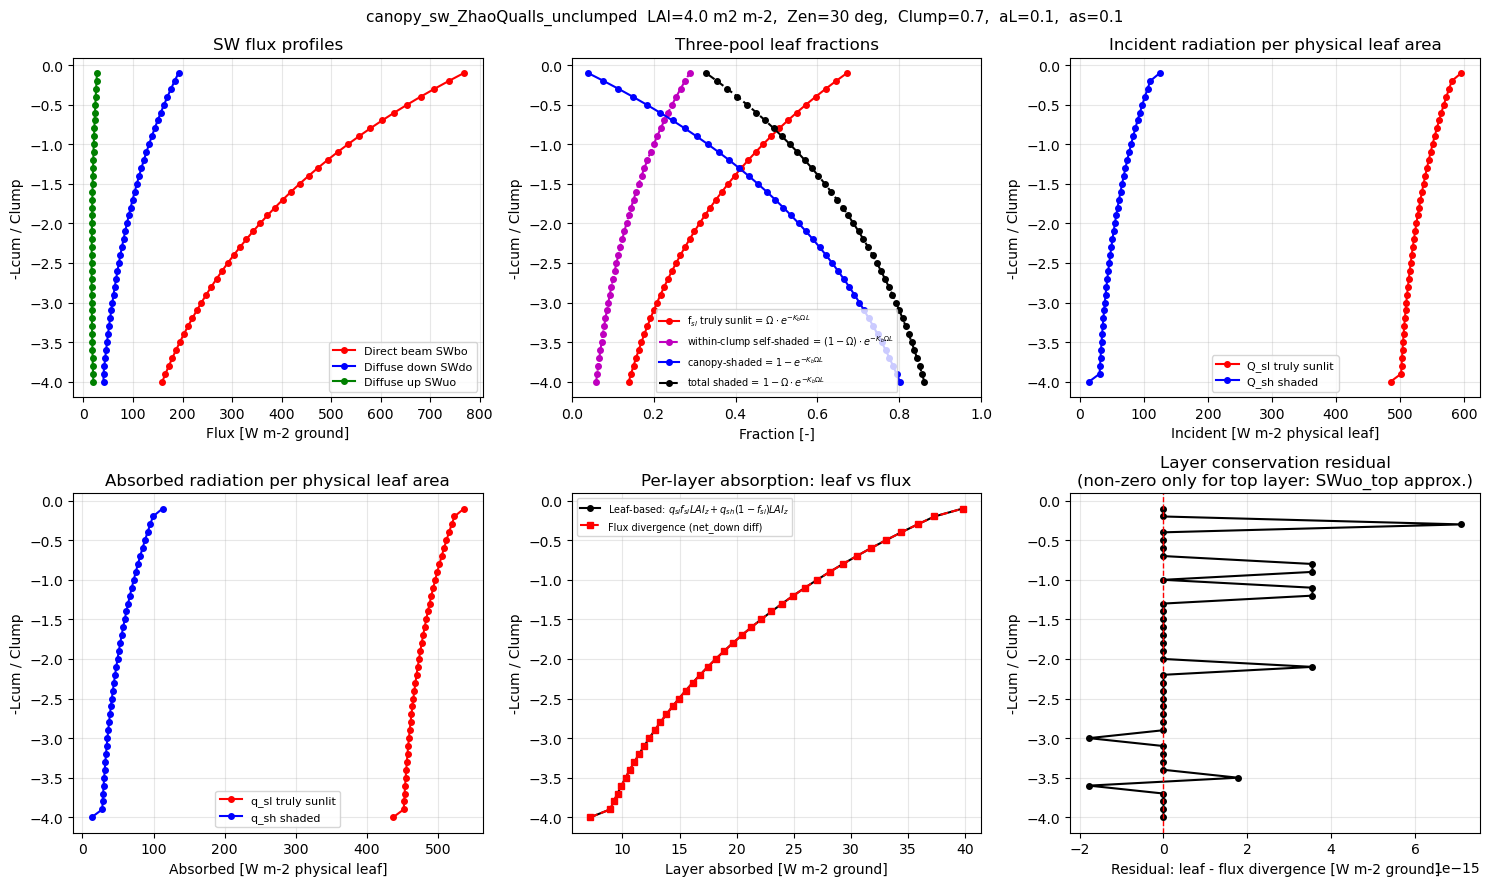

Global energy budget
  Incident (beam + diffuse):  1000.00 W m-2
  Reflected (canopy albedo):    27.27 W m-2  (alb=0.0273)
  Absorbed by leaves:          793.15 W m-2
  Absorbed by soil:            179.58 W m-2
  Residual (should be ~0):     0.0000 W m-2  (0.000 %)

Per-layer conservation  [W m-2 ground]
Layer    abs_leaf    abs_flux        diff     rel%
    0      7.1915      7.1915     +0.0000     0.00%
    1      8.9270      8.9270     +0.0000     0.00%
    2      9.2397      9.2397     +0.0000     0.00%
    3      9.5677      9.5677     +0.0000     0.00%
    4      9.9119      9.9119     -0.0000    -0.00%
    5     10.2728     10.2728     +0.0000     0.00%
    6     10.6509     10.6509     +0.0000     0.00%
    7     11.0470     11.0470     +0.0000     0.00%
    8     11.4616     11.4616     +0.0000     0.00%
    9     11.8954     11.8954     +0.0000     0.00%
   10     12.3491     12.3491     -0.0000    -0.00%
   11     12.8234     12.8234     +0.0000     0.00%
   12     13.3191  

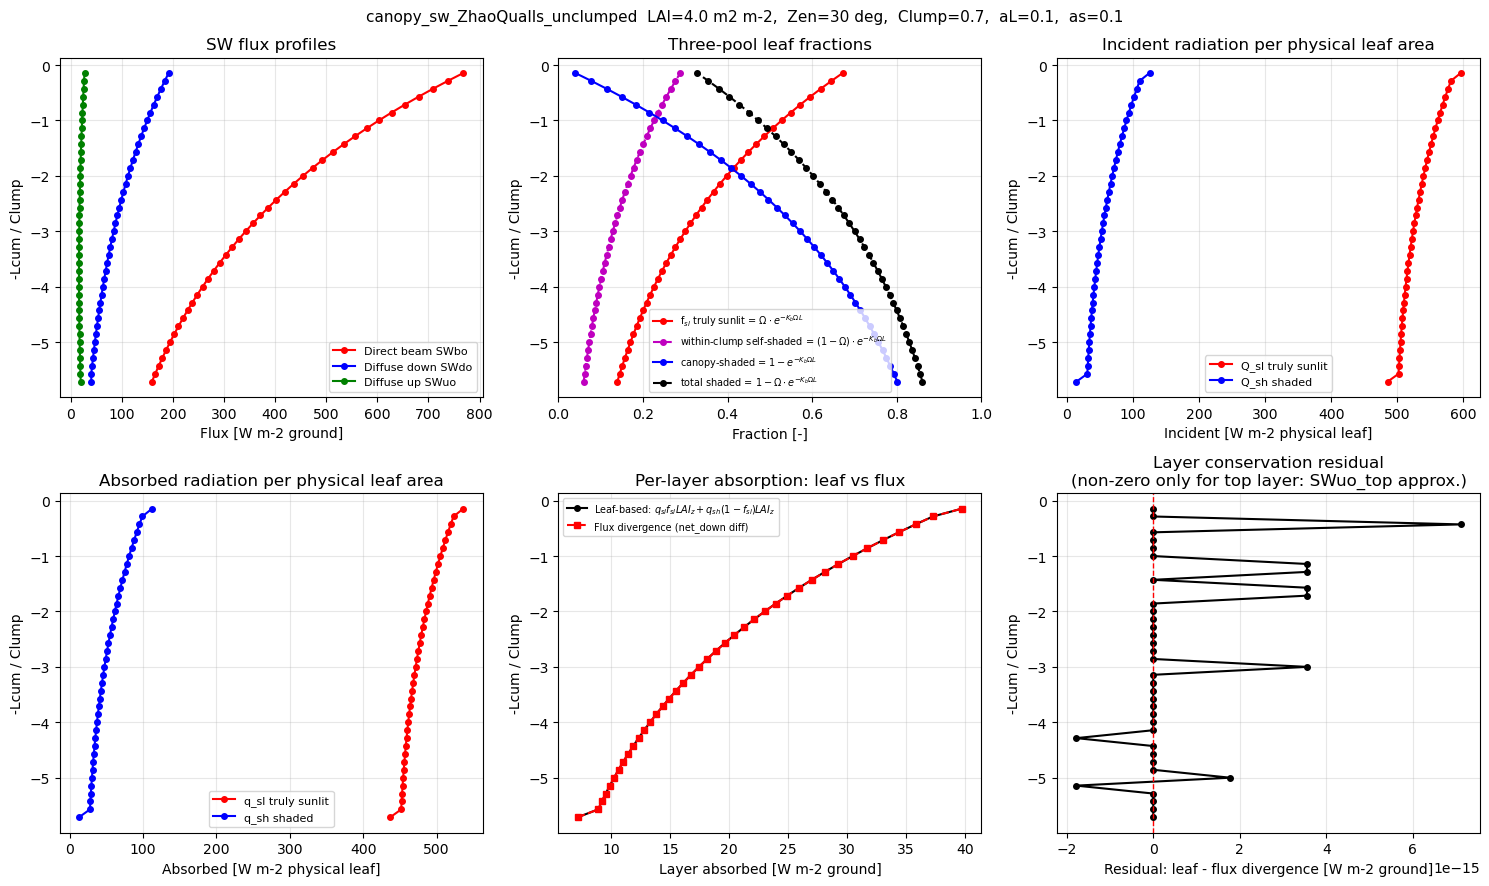

In [ ]:

# ============================================================
#  Test: canopy_sw_ZhaoQualls_unclumped — profiles + energy conservation
# ============================================================

# ---- Inputs ----
LAIz       = np.ones(40) * 0.1          # 40 layers, total LAI = 4 m2 m-2
Clump      = 0.7                         # clumping index
x          = 1.0                         # spherical LAD
Zen        = np.radians(30.)
IbSky      = 800.0                       # W m-2 direct beam
IdSky      = 200.0                       # W m-2 diffuse
LeafAlbedo = 0.10
SoilAlbedo = 0.10

SWbo, SWdo, SWuo, Q_sl, Q_sh, q_sl, q_sh, q_soil, f_sl, alb = \
    canopy_sw_ZhaoQualls_unclumped(LAIz, Clump, x, Zen, IbSky, IdSky,
                         LeafAlbedo, SoilAlbedo, PlotFigs=True)

N   = len(LAIz)
# Cumulative physical LAI from canopy top at the bottom edge of each layer
Lcumo = np.flipud(np.cumsum(np.flipud(LAIz)))
depth = -Lcumo / Clump   # y-axis: 0 near top, -LAI/Clump at bottom

# ============================================================
#  Energy conservation
# ============================================================
# f_sl (returned) = truly sunlit fraction of physical leaf area
#                 = Clump * exp(-Kb * Clump * cumsum(LAIz))
# Truly sunlit physical leaf area per layer  = f_sl * LAIz
# Shaded physical leaf area per layer
#   (incl. within-clump self-shaded)         = (1 - f_sl) * LAIz
#
# Build (N+1)-length interface arrays: index 0 = soil, index N = canopy top
SWbo_int = np.append(SWbo, IbSky)
SWdo_int = np.append(SWdo, IdSky)
SWuo_int = np.append(SWuo, alb * (IbSky + IdSky))

# Net downward flux at each interface [W m-2 ground]
net_down = SWbo_int + SWdo_int - SWuo_int

# Per-layer absorbed from flux divergence (exact):
abs_flux = np.diff(net_down)   # positive = absorbed [W m-2 ground]

# Per-layer absorbed from leaf quantities:
#   q_sl, q_sh are per unit physical leaf area; LAIz is the physical layer LAI
#   f_sl = truly sunlit fraction (= Clump * exp(-Kb * Clump * LAI_cum))
#   abs_leaf = q_sl * f_sl * LAIz + q_sh * (1 - f_sl) * LAIz  (exact, by construction)
abs_leaf = q_sl * f_sl * LAIz + q_sh * (1 - f_sl) * LAIz

# ---- Global budget ----
total_incident   = IbSky + IdSky
total_reflected  = alb * total_incident
total_abs_leaves = np.sum(abs_leaf)
residual         = total_incident - total_reflected - total_abs_leaves - q_soil

print("=" * 55)
print("Global energy budget")
print("=" * 55)
print(f"  Incident (beam + diffuse): {total_incident:8.2f} W m-2")
print(f"  Reflected (canopy albedo): {total_reflected:8.2f} W m-2  (alb={alb:.4f})")
print(f"  Absorbed by leaves:        {total_abs_leaves:8.2f} W m-2")
print(f"  Absorbed by soil:          {q_soil:8.2f} W m-2")
print(f"  Residual (should be ~0):   {residual:8.4f} W m-2  ({100*residual/total_incident:.3f} %)")

print()
print("Per-layer conservation  [W m-2 ground]")
print(f"{'Layer':>5}  {'abs_leaf':>10}  {'abs_flux':>10}  {'diff':>10}  {'rel%':>7}")
for k in range(N):
    d   = abs_leaf[k] - abs_flux[k]
    rel = 100 * d / abs_flux[k] if abs(abs_flux[k]) > 1e-6 else float('nan')
    print(f"{k:>5}  {abs_leaf[k]:>10.4f}  {abs_flux[k]:>10.4f}  {d:>+10.4f}  {rel:>7.2f}%")

print()
print(f"Soil absorbed (net_down at soil):  {net_down[0]:.4f}  vs  q_soil: {q_soil:.4f}")
print()
print(f"Truly sunlit LAI (sum f_sl*LAIz):  {np.sum(f_sl*LAIz):.3f}  m2 m-2")
print(f"  of which within-clump self-shaded moved to shaded pool: {np.sum((1-Clump)*np.exp(-kbeam(Zen,1.0)*Clump*Lcumo)*LAIz):.3f}")
print(f"Shaded LAI (sum (1-f_sl)*LAIz):    {np.sum((1-f_sl)*LAIz):.3f}  m2 m-2")

# ============================================================
#  Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    f"canopy_sw_ZhaoQualls_unclumped  LAI={sum(LAIz):.1f} m2 m-2,  Zen={np.degrees(Zen):.0f} deg,"
    f"  Clump={Clump},  aL={LeafAlbedo},  as={SoilAlbedo}",
    fontsize=11)

# SW flux profiles
ax = axes[0, 0]
ax.plot(SWbo, depth, 'r-o', ms=4, label='Direct beam SWbo')
ax.plot(SWdo, depth, 'b-o', ms=4, label='Diffuse down SWdo')
ax.plot(SWuo, depth, 'g-o', ms=4, label='Diffuse up SWuo')
ax.set_xlabel('Flux [W m-2 ground]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('SW flux profiles')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Sunlit / shaded fractions (truly sunlit = Clump * between-clump gap fraction)
ax = axes[0, 1]
f_between_clump = np.exp(-kbeam(Zen, x) * Clump * Lcumo)  # between-clump sunlit fraction.
ax.plot(f_sl, depth, 'r-o', ms=4, label=r'f$_{sl}$ truly sunlit = $\Omega \cdot e^{-K_b \Omega L}$')
ax.plot(f_between_clump - f_sl, depth, 'm--o', ms=4, label=r'within-clump self-shaded = $(1-\Omega) \cdot e^{-K_b \Omega L}$')
ax.plot(1 - f_between_clump, depth, 'b-o', ms=4, label=r'canopy-shaded = $1 - e^{-K_b \Omega L}$')
ax.plot(1 - f_sl, depth, 'k--o', ms=4, label=r'total shaded = $1 - \Omega \cdot e^{-K_b \Omega L}$')
ax.set_xlabel('Fraction [-]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('Three-pool leaf fractions')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

# Incident per physical leaf area
ax = axes[0, 2]
ax.plot(Q_sl, depth, 'r-o', ms=4, label='Q_sl truly sunlit')
ax.plot(Q_sh, depth, 'b-o', ms=4, label='Q_sh shaded')
ax.set_xlabel('Incident [W m-2 physical leaf]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('Incident radiation per physical leaf area')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Absorbed per physical leaf area
ax = axes[1, 0]
ax.plot(q_sl, depth, 'r-o', ms=4, label='q_sl truly sunlit')
ax.plot(q_sh, depth, 'b-o', ms=4, label='q_sh shaded')
ax.set_xlabel('Absorbed [W m-2 physical leaf]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('Absorbed radiation per physical leaf area')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Per-layer conservation comparison
ax = axes[1, 1]
ax.plot(abs_leaf, depth, 'k-o',  ms=4, label=r'Leaf-based: $q_{sl} f_{sl} LAI_z + q_{sh}(1-f_{sl})LAI_z$')
ax.plot(abs_flux, depth, 'r--s', ms=4, label='Flux divergence (net_down diff)')
ax.set_xlabel('Layer absorbed [W m-2 ground]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('Per-layer absorption: leaf vs flux')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Residual
ax = axes[1, 2]
ax.plot(abs_leaf - abs_flux, depth, 'k-o', ms=4)
ax.axvline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Residual: leaf - flux divergence [W m-2 ground]')
ax.set_ylabel('-Lcum / Clump')
ax.set_title('Layer conservation residual\n(non-zero only for top layer: SWuo_top approx.)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
225. / 8

28.125